Skoro interesuje nas **wartość** gradientu, to może wykorzystajmy definicję pochodnej:

![derivative-limit](https://wikimedia.org/api/rest_v1/media/math/render/svg/28c61f16be60a66e84a24082529dee3c47a174b7)

In [1]:
function g(x, y)
    r = 1.0
    for i=1:y
        r *= x
    end
    return r
end

forward_diff(f, x_0; Δx=1e-3) = ( f(x_0 + Δx) - f(x_0) ) / Δx

Δx = 1e-9
x_0 = 5.
y_0 = 3

f(x) = g(x, y_0)
dgdx = forward_diff(f, x_0; Δx=Δx)

75.00000265281415

W rzeczywistości `g(x, y)` oblicza wartość `x^y`, więc jego pochodna dana jest wzorem:

In [2]:
dg(x, y) = y*x^(y-1)
dg(x_0, y_0)

75.0

Zmniejszając krok $\Delta x$ teoretycznie powinniśmy dostać idealne rozwiązanie, jednak wcale tak nie będzie:

In [3]:
Δx = 10.0.^(-15.:0.1:0.);
Eforward  = similar(Δx)
for i=1:length(Δx)
    Eforward[i] = forward_diff(f, x_0; Δx=Δx[i]) - dg(x_0, y_0);
end

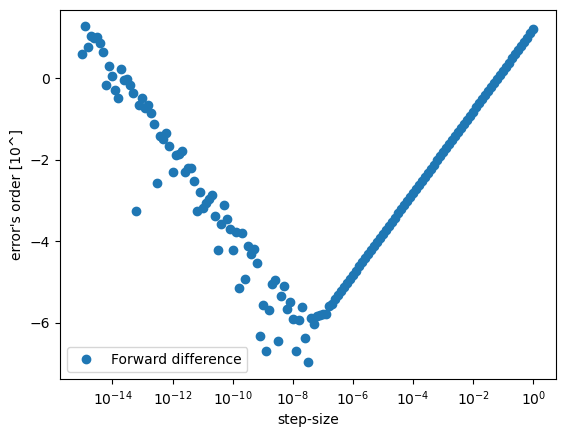

PyObject Text(24.000000000000007, 0.5, "error's order [10^]")

In [ ]:
using PythonPlot
semilogx(Δx, log10.(abs.(Eforward)), "o")
legend(("Forward difference", "Central difference", "Complex difference"))
xlabel("step-size")
ylabel("error's order [10^]")

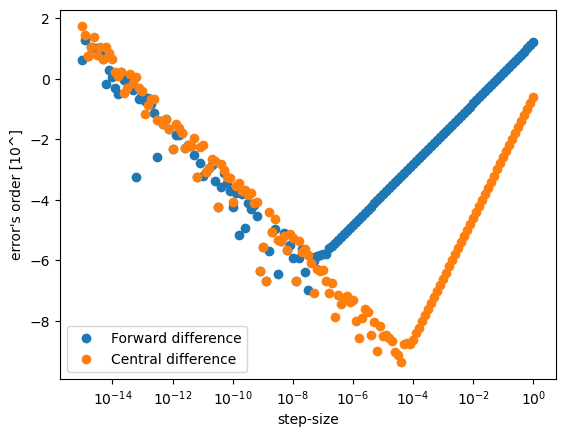

PyObject Text(24.000000000000007, 0.5, "error's order [10^]")

In [ ]:
center_diff(f, x_0; Δx=1e-3) = ( f(x_0 + 0.5Δx) - f(x_0 - 0.5Δx) ) / Δx
Ecenter = similar(Δx)
for i=1:length(Δx)
    Ecenter[i]  = center_diff(f, x_0; Δx=Δx[i]) - dg(x_0, y_0);
end
using PythonPlot
semilogx(Δx, log10.(abs.(Eforward)), "o")
semilogx(Δx, log10.(abs.(Ecenter)), "o")
legend(("Forward difference", "Central difference", "Complex difference"))
xlabel("step-size")
ylabel("error's order [10^]")

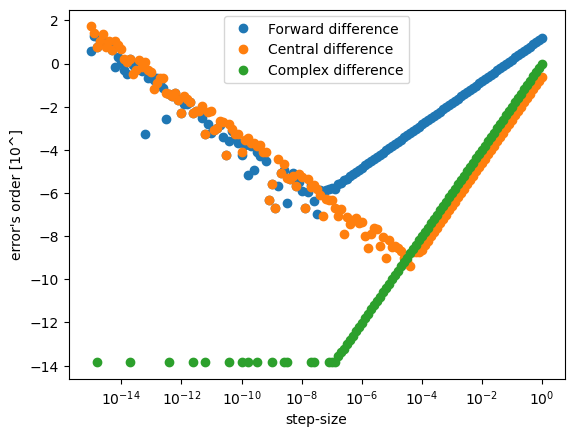

PyObject Text(24.000000000000007, 0.5, "error's order [10^]")

In [ ]:
complex_diff(f, x_0; Δx=1e-3) = imag(f(x_0 + Δx * 1im)) / Δx
Ecomplex = similar(Δx)
for i=1:length(Δx)
    Ecomplex[i]  = complex_diff(f, x_0; Δx=Δx[i]) - dg(x_0, y_0);
end

using PythonPlot
semilogx(Δx, log10.(abs.(Eforward)), "o")
semilogx(Δx, log10.(abs.(Ecenter)),  "o")
semilogx(Δx, log10.(abs.(Ecomplex)), "o")
legend(("Forward difference", "Central difference", "Complex difference"))
xlabel("step-size")
ylabel("error's order [10^]")